In [1]:
from google.colab import files


uploaded = files.upload()

Saving 107.circles to 107.circles
Saving 107.edges to 107.edges
Saving 107.egofeat to 107.egofeat
Saving 107.feat to 107.feat
Saving 107.featnames to 107.featnames


In [2]:
import networkx as nx
import numpy as np
from collections import Counter
from itertools import chain
import scipy.stats
from scipy.stats import linregress
import matplotlib.pyplot as plt

Xây dựng đồ thị từ dữ liệu

In [5]:
G = nx.Graph()
with open('107.edges', 'r') as f:
    for line in f:
        if line.strip():
            u, v = map(int, line.strip().split())
            G.add_edge(u, v)

**Thống kê cơ bản về mạng lưới**:

Số lượng nút và cạnh

In [6]:
print('Number of nodes:', G.number_of_nodes())
print('Number of edges:', G.number_of_edges())

Number of nodes: 1034
Number of edges: 26749


Đường kính, bán kính

In [7]:
print('Diameter:', nx.diameter(G))
print('Radius:', nx.radius(G))

Diameter: 9
Radius: 5


Phân tích Hệ số phân cụm (Clustering Coefficient)

In [9]:
transitivity = nx.transitivity(G)
avg_clustering = nx.average_clustering(G)
local_cc = nx.clustering(G)
cc_values = list(local_cc.values())
cc_hist, cc_bins = np.histogram(cc_values, bins=10)

print('Transitivity:', transitivity)
print('Average Clustering Coefficient:', avg_clustering)
print('Clustering Coefficient):', local_cc)
print('Clustering Coefficient Histogram:', cc_hist)
print('Clustering Coefficient Bins:', cc_bins)

Transitivity: 0.5045088189930924
Average Clustering Coefficient: 0.5264047980773338
Clustering Coefficient): {953: 0.5339217722395293, 1323: 0.6049122807017544, 1789: 0.5791108522616968, 1707: 0.4885958660014255, 1175: 0.44274809160305345, 1059: 0.5127188388448302, 1329: 0.48756218905472637, 1559: 0.47937720329024675, 1804: 0.46797713797339885, 1898: 0.5874747474747475, 1622: 0.45720779220779223, 1520: 0.532983508245877, 1200: 0.3333333333333333, 1202: 0.10714285714285714, 1449: 0.5612870275791624, 1836: 0.6014492753623188, 1156: 0.5285083105407111, 1605: 0.6013789581205311, 1149: 0.5819801980198019, 1173: 0.4393727682036951, 1180: 0.6522198731501057, 1549: 0.27393617021276595, 1412: 0.36666666666666664, 1638: 0.678030303030303, 942: 0.5724206349206349, 1448: 0.6235294117647059, 1786: 0.4274122807017544, 1768: 0.4044035674470457, 1092: 0.5025510204081632, 927: 0.5701592002961866, 1791: 0.507334525939177, 1287: 0.7163461538461539, 1516: 0.5763121825364831, 1044: 0.7606837606837606, 1235

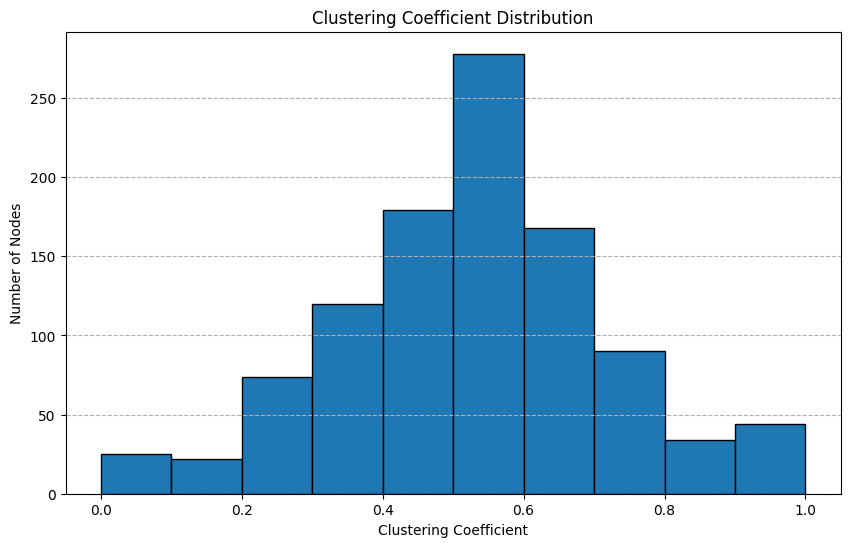

In [29]:
plt.figure(figsize=(10, 6))
plt.bar(cc_bins[:-1], cc_hist, width=np.diff(cc_bins), edgecolor='black', align='edge')
plt.title('Clustering Coefficient Distribution')
plt.xlabel('Clustering Coefficient')
plt.ylabel('Number of Nodes')
plt.grid(axis='y', linestyle='--')
plt.show()

Phân tích Độ dài đường đi trung bình (average shortest path length)

In [32]:
avg_shortest_path = nx.average_shortest_path_length(G)
path_lengths = []
for u in G.nodes():
    lengths = nx.single_source_shortest_path_length(G, u)
    for v in lengths:
        if u < v:
            path_lengths.append(lengths[v])
spath_hist, spath_bins = np.histogram(path_lengths, bins=range(1, 11))

print('Average Shortest Path Length:', avg_shortest_path)
print('Shortest Path Length Histogram:', spath_hist)
print('Shortest Path Length Bins:', spath_bins)

Average Shortest Path Length: 2.951675932150073
Shortest Path Length Histogram: [ 26749 135236 232710 118229  18950   1971    197     18      1]
Shortest Path Length Bins: [ 1  2  3  4  5  6  7  8  9 10]


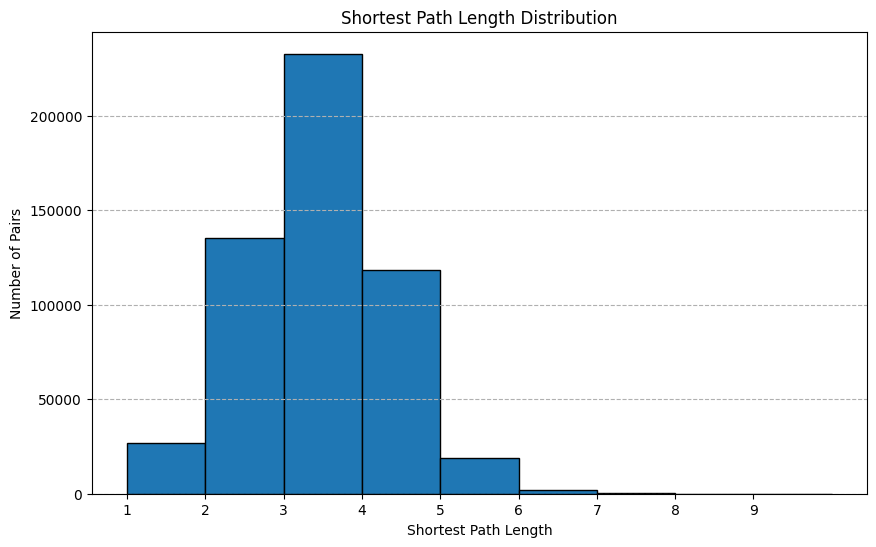

In [30]:
plt.figure(figsize=(10, 6))
plt.bar(spath_bins[:-1], spath_hist, width=np.diff(spath_bins), edgecolor='black', align='edge')
plt.title('Shortest Path Length Distribution')
plt.xlabel('Shortest Path Length')
plt.ylabel('Number of Pairs')
plt.xticks(spath_bins[:-1])
plt.grid(axis='y', linestyle='--')
plt.show()

Phân phối bậc (degree distribution) và mô hình đánh giá bằng hồi quy (power-law fit)

In [20]:
degrees = [d for n, d in G.degree()]
deg_count = Counter(degrees)
k = np.array(sorted(deg_count.keys()))
p = np.array([deg_count[ki] / len(degrees) for ki in k])
mask = (k > 0) & (p > 0)
logk = np.log(k[mask])
logp = np.log(p[mask])
slope, intercept = np.polyfit(logk, logp, 1)
alpha = -slope

print('Alpha:', alpha)
print('Slope:', slope)
print('Intercept:', intercept)

Alpha: 0.8118254766006713
Slope: -0.8118254766006713
Intercept: -2.1687035109297605


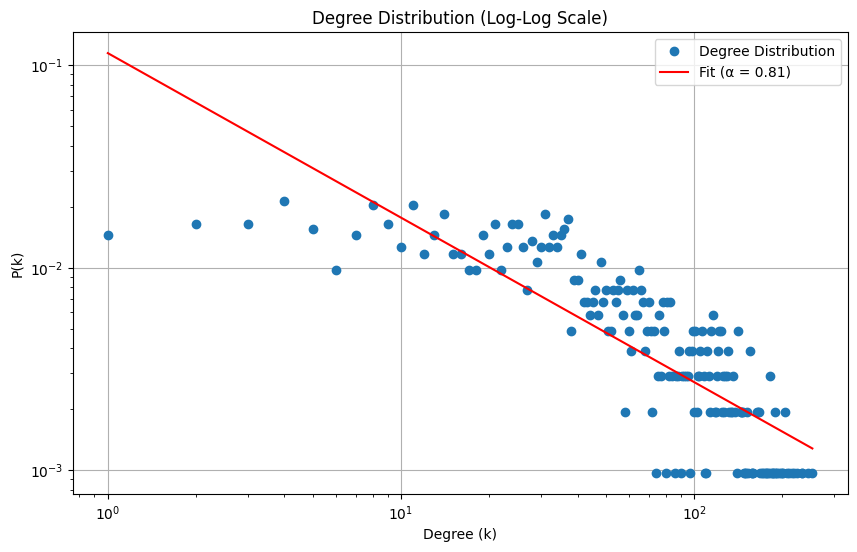

In [28]:
plt.figure(figsize=(10, 6))
plt.loglog(k, p, 'o', label='Degree Distribution')
plt.loglog(k[mask], np.exp(intercept + slope * logk), 'r-', label=f'Fit (α = {alpha:.2f})')
plt.title('Degree Distribution (Log-Log Scale)')
plt.xlabel('Degree (k)')
plt.ylabel('P(k)')
plt.legend()
plt.grid(True)
plt.show()